<a href="https://colab.research.google.com/github/Ishini01/garment_defect_system/blob/main/Color_Imbalance_ResNEt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Setup

Imports, mounts Google Drive, and defines the dataset paths and image size
used throughout this notebook.


In [ ]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from google.colab import drive, files

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

drive.mount('/content/drive')

DATASET_PATH = '/content/drive/MyDrive/Garment_Defect_Dataset/raw_images/ColorImbalance/Images'
BALANCED_DIR = os.path.join(DATASET_PATH, 'Balanced')
IMBALANCED_DIR = os.path.join(DATASET_PATH, 'Imbalanced')
valid_ext = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')
IMG_SIZE = (224, 224)

np.random.seed(42)
tf.random.set_seed(42)

print(f"Balanced: {len(os.listdir(BALANCED_DIR))} images")
print(f"Imbalanced: {len(os.listdir(IMBALANCED_DIR))} images")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Balanced: 1660 images
Imbalanced: 1600 images


## 2. Load Dataset

Loads every image as RGB at raw 0-255 pixel values (no manual scaling -
`preprocess_input` handles that later, matching ResNet50's expected input
format). Tracks whether each image is an original/augmented real photo or
a synthetically generated defect, for later reference.


In [ ]:
def load_image(path, target_size=IMG_SIZE):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        return None
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return cv2.resize(img_rgb, target_size).astype(np.float32)


images, labels, sources = [], [], []
for label, folder in [(0, BALANCED_DIR), (1, IMBALANCED_DIR)]:
    for fname in os.listdir(folder):
        if not fname.lower().endswith(valid_ext):
            continue
        img = load_image(os.path.join(folder, fname))
        if img is None:
            continue
        images.append(img)
        labels.append(label)
        sources.append('synthetic' if fname.startswith('synthetic_') else 'real')

images = np.array(images)
labels = np.array(labels)
sources = np.array(sources)

print(f"Loaded {len(images)} images: {np.sum(labels==0)} Balanced, {np.sum(labels==1)} Imbalanced")


Loaded 3200 images: 1600 Balanced, 1600 Imbalanced


## 3. Train / Validation / Test Split

Splits the dataset 70/15/15 into training, validation, and test sets,
stratified by label so both classes are proportionally represented in
each split.


In [ ]:
idx = np.arange(len(images))
idx_train, idx_temp = train_test_split(idx, test_size=0.3, random_state=42, stratify=labels)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.5, random_state=42, stratify=labels[idx_temp])

X_train, y_train = images[idx_train], labels[idx_train]
X_val, y_val = images[idx_val], labels[idx_val]
X_test, y_test = images[idx_test], labels[idx_test]
sources_test = sources[idx_test]

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


Train: 2240, Val: 480, Test: 480


## 4. Build the ResNet50 Model

A ResNet50 backbone (pretrained on ImageNet, initially frozen) with a
custom classification head. Dropout and L2 regularization are used to
reduce overfitting given the moderate dataset size.


In [ ]:
def build_resnet_model(input_shape=(224, 224, 3)):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False
    return models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.6),
        layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid'),
    ])

model = build_resnet_model()
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,719,169 (90.48 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 23,587,840 (89.98 MB)

## 5. Train (Phase 1: Frozen Base)

Trains only the classification head, with the ResNet50 backbone frozen.
Early stopping monitors validation accuracy and restores the best
checkpoint rather than the final epoch's weights.


In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15, width_shift_range=0.1, height_shift_range=0.1,
    horizontal_flip=True, zoom_range=0.1, brightness_range=[0.9, 1.1], fill_mode='nearest',
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')],
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', mode='max', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
]

history = model.fit(
    train_datagen.flow(X_train, y_train, batch_size=16),
    steps_per_epoch=max(1, len(X_train) // 16),
    epochs=50,
    validation_data=val_datagen.flow(X_val, y_val, batch_size=16, shuffle=False),
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 511s 4s/step - accuracy: 0.6174 - loss: 1.6768 - precision: 0.6171 - recall: 0.6187 - val_accuracy: 0.7354 - val_loss: 1.2296 - val_precision: 0.6647 - val_recall: 0.9500 - learning_rate: 0.0010
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 485s 3s/step - accuracy: 0.7040 - loss: 1.2314 - precision: 0.7083 - recall: 0.6938 - val_accuracy: 0.7688 - val_loss: 0.9959 - val_precision: 0.7009 - val_recall: 0.9375 - learning_rate: 0.0010
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 490s 4s/step - accuracy: 0.7223 - loss: 1.0505 - precision: 0.7207 - recall: 0.7259 - val_accuracy: 0.8146 - val_loss: 0.8581 - val_precision: 0.7849 - val_recall: 0.8667 - learning_rate: 0.0010
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 498s 3s/step - accuracy: 0.7161 - loss: 0.9327 - precision: 0.7176 - recall: 0.7125 - val_accuracy: 0.8083 - val_loss: 0.7818 - val_precision: 0.7913 - val_recall: 0.8375 - learning_rate: 0.0010
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 499s 3s/step - accur

## 6. Fine-Tune (Phase 2: Partial Unfreeze)

Unfreezes only the last 30 layers of the ResNet50 backbone (not the whole
network) and continues training at a much lower learning rate. Keeping
most of the backbone frozen limits trainable parameters relative to the
dataset size, reducing overfitting risk.


In [ ]:
base_model = model.layers[0]
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')],
)

history_fine = model.fit(
    train_datagen.flow(X_train, y_train, batch_size=16),
    steps_per_epoch=max(1, len(X_train) // 16),
    epochs=15,
    validation_data=val_datagen.flow(X_val, y_val, batch_size=16, shuffle=False),
    callbacks=callbacks,
    verbose=1,
)

for key in history.history:
    if key in history_fine.history:
        history.history[key].extend(history_fine.history[key])


Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 708s 5s/step - accuracy: 0.7804 - loss: 0.6341 - precision: 0.7875 - recall: 0.7679 - val_accuracy: 0.8521 - val_loss: 0.5154 - val_precision: 0.8340 - val_recall: 0.8792 - learning_rate: 1.0000e-05
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 676s 5s/step - accuracy: 0.8250 - loss: 0.5778 - precision: 0.8447 - recall: 0.7964 - val_accuracy: 0.8833 - val_loss: 0.4711 - val_precision: 0.8651 - val_recall: 0.9083 - learning_rate: 1.0000e-05
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 674s 5s/step - accuracy: 0.8513 - loss: 0.5114 - precision: 0.8667 - recall: 0.8304 - val_accuracy: 0.8875 - val_loss: 0.4413 - val_precision: 0.8875 - val_recall: 0.8875 - learning_rate: 1.0000e-05
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 683s 5s/step - accuracy: 0.8638 - loss: 0.4910 - precision: 0.8885 - recall: 0.8321 - val_accuracy: 0.9042 - val_loss: 0.4265 - val_precision: 0.9110 - val_recall: 0.8958 - learning_rate: 1.0000e-05
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 684s

## 7. Training and Validation Curves

Plots accuracy and loss across both training phases, combined into one
continuous curve.


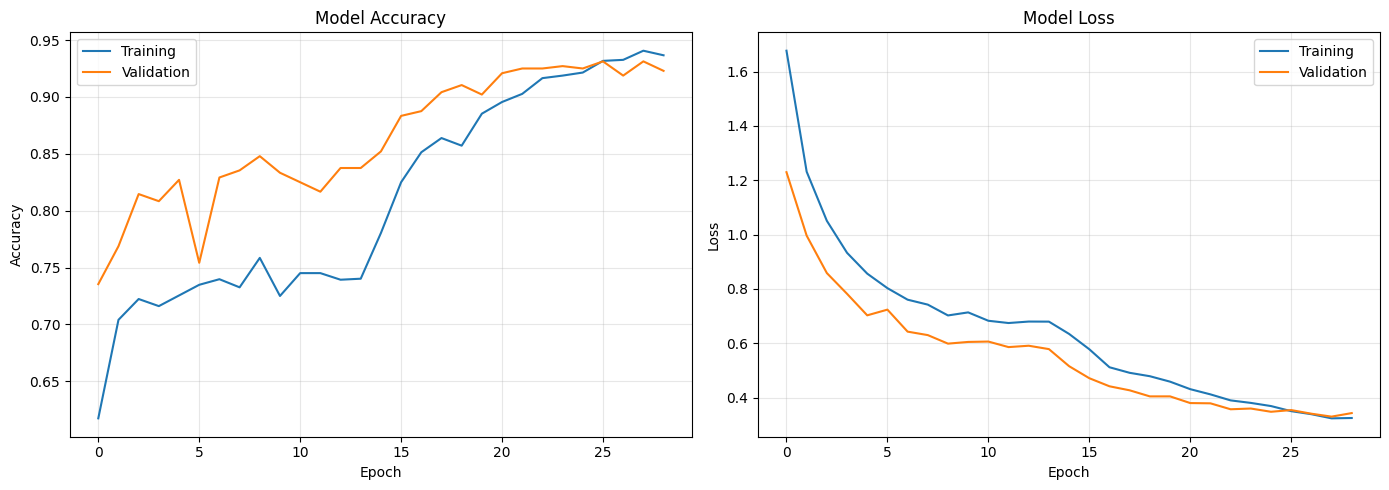

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], label='Training')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Training')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Evaluate on the Test Set

Reports Accuracy, Precision, Recall, and F1-score on the held-out test
set, along with a confusion matrix.


Overall Accuracy: 91.67%
Precision: 95.05%  Recall: 87.92%  F1: 91.34%


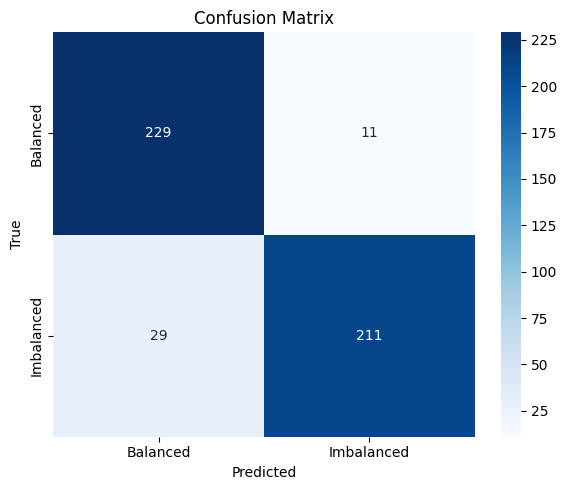

In [ ]:
X_test_pre = preprocess_input(X_test.copy())
y_pred_proba = model.predict(X_test_pre, verbose=0).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)

print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.2%}  Recall: {recall_score(y_test, y_pred, zero_division=0):.2%}  F1: {f1_score(y_test, y_pred, zero_division=0):.2%}")

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Balanced', 'Imbalanced'], yticklabels=['Balanced', 'Imbalanced'])
plt.title('Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.show()

## 9. Sample Predictions on the Test Set

Displays a random sample of test images with their true label vs. the
model's predicted label side by side, so correct and incorrect
predictions can be inspected visually.


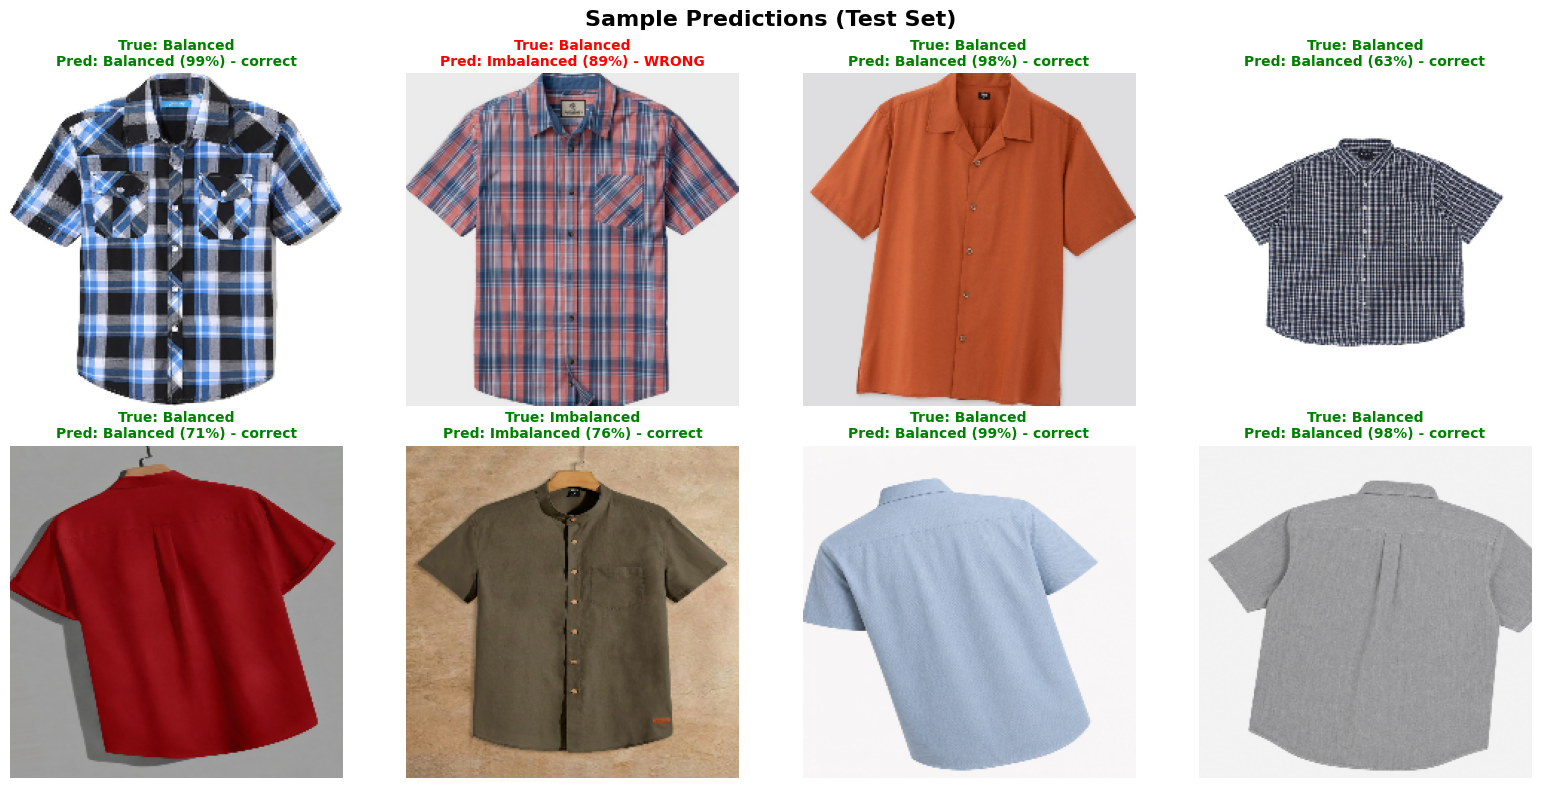

In [ ]:
sample_idx = random.sample(range(len(X_test)), min(8, len(X_test)))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, idx in zip(axes.flat, sample_idx):
    true_label = "Imbalanced" if y_test[idx] == 1 else "Balanced"
    pred_label = "Imbalanced" if y_pred[idx] == 1 else "Balanced"
    confidence = y_pred_proba[idx] if y_pred[idx] == 1 else 1 - y_pred_proba[idx]

    img = X_test[idx].astype(np.uint8)
    ax.imshow(img)

    correct = (true_label == pred_label)
    color = 'green' if correct else 'red'
    mark = "correct" if correct else "WRONG"
    ax.set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.0%}) - {mark}",
                 color=color, fontsize=10, fontweight='bold')
    ax.axis('off')
plt.suptitle("Sample Predictions (Test Set)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Save the Trained Model

Persists the trained model to Google Drive so it can be reloaded for
inference without retraining.


In [ ]:
MODEL_PATH = '/content/drive/MyDrive/Garment_Defect_Dataset/color_imbalance_resnet_model.h5'
model.save(MODEL_PATH)
print(f"Saved to {MODEL_PATH}")

Saved to /content/drive/MyDrive/Garment_Defect_Dataset/color_imbalance_resnet_model.h5


## 11. Inference on a New Image

Uploads a new shirt image and runs the trained model on it, displaying
the image together with the predicted status (Balanced/Imbalanced) and
confidence score.


Saving ChatGPT Image Aug 31, 2026, 07_51_28 PM.png to ChatGPT Image Aug 31, 2026, 07_51_28 PM.png
Prediction: Imbalanced
Confidence: 92.73%


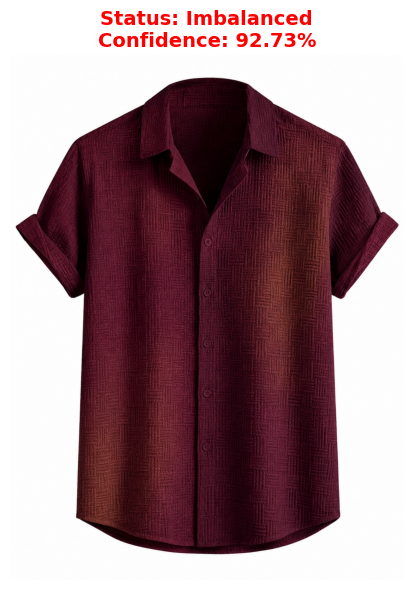

In [22]:
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

img = load_image(image_path)
img_pre = preprocess_input(np.expand_dims(img.copy(), axis=0))
pred = model.predict(img_pre, verbose=0)[0][0]
status = 'Imbalanced' if pred > 0.5 else 'Balanced'
confidence = pred if pred > 0.5 else 1 - pred

print(f"Prediction: {status}")
print(f"Confidence: {confidence:.2%}")

img_rgb = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
color = 'red' if status == 'Imbalanced' else 'green'
plt.title(f"Status: {status}\nConfidence: {confidence:.2%}", color=color, fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()


Saving Gemini_Generated_Image_6av94t6av94t6av9.jpg to Gemini_Generated_Image_6av94t6av94t6av9.jpg
Prediction: Balanced
Confidence: 81.16%


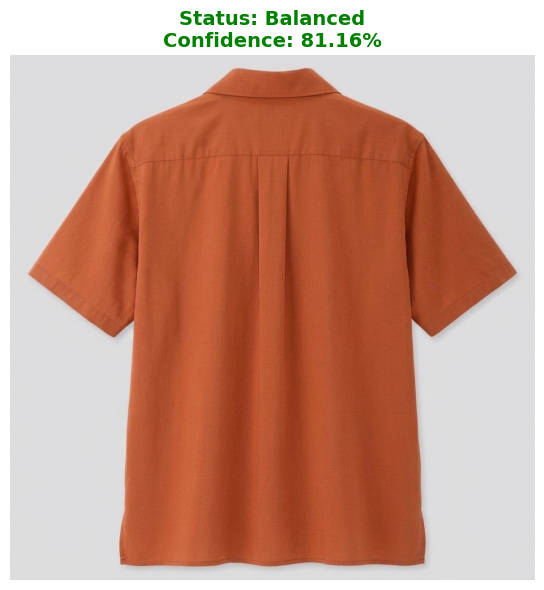

In [23]:
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

img = load_image(image_path)
img_pre = preprocess_input(np.expand_dims(img.copy(), axis=0))
pred = model.predict(img_pre, verbose=0)[0][0]
status = 'Imbalanced' if pred > 0.5 else 'Balanced'
confidence = pred if pred > 0.5 else 1 - pred

print(f"Prediction: {status}")
print(f"Confidence: {confidence:.2%}")

img_rgb = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
color = 'red' if status == 'Imbalanced' else 'green'
plt.title(f"Status: {status}\nConfidence: {confidence:.2%}", color=color, fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()
